In [2]:
from torchvision import datasets
from torchvision.transforms import ToTensor



In [3]:
train_data=datasets.MNIST(
    root='data',
    train = True,
    download=True,
    transform=ToTensor()
)

test_data=datasets.MNIST(
    root='data',
    train = False,
    download=True,
    transform=ToTensor()
)

In [4]:
train_data.data

tensor([[[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        ...,

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         ...,
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0]],

        [[0, 0, 0,  ..., 0, 0, 0],
         [0, 0, 0,  ..., 0, 0, 0],
         [0,

In [5]:
train_data.data.shape

torch.Size([60000, 28, 28])

In [6]:
train_data

Dataset MNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [7]:
test_data

Dataset MNIST
    Number of datapoints: 10000
    Root location: data
    Split: Test
    StandardTransform
Transform: ToTensor()

In [8]:
test_data.data.shape


torch.Size([10000, 28, 28])

In [9]:
train_data.targets

tensor([5, 0, 4,  ..., 5, 6, 8])

In [10]:
train_data.targets.size()

torch.Size([60000])

In [11]:
from torch.utils.data import DataLoader

loaders={
    'train': DataLoader(train_data,
                        batch_size=100,
                        num_workers=1,
                        shuffle=True
    ),

    'test': DataLoader(test_data,
                        batch_size=100,
                        num_workers=1,
    )
    

}

In [12]:
loaders

{'train': <torch.utils.data.dataloader.DataLoader at 0x79354c16ce50>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x793503629490>}

In [13]:
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.conv2d_drop = nn.Dropout2d()
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = F.relu(F.max_pool2d(self.conv1(x), 2))
        x = F.relu(F.max_pool2d(self.conv2(x), 2))
        x = self.conv2d_drop(x)
        x = x.view(-1, 320)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, training=self.training)
        x = self.fc2(x)
        return x


In [14]:
import torch 

device= torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = CNN().to(device)

optimizer= optim.Adam(model.parameters(),lr=0.01)

loss_fn=nn.CrossEntropyLoss()

def train(epoch):
    model.train()
    for batch_idx, (data,target) in enumerate(loaders['train']):
        data,target= data.to(device), target.to(device)
        optimizer.zero_grad()
        output=model(data)
        loss=loss_fn(output,target)
        loss.backward()
        optimizer.step()

        if batch_idx % 20==0:
           print(
    f"Train epoch: {epoch} "
    f"[{batch_idx * len(data)}/{len(loaders['train'].dataset)} "
    f"({100 * batch_idx / len(loaders['train']):.0f}%)] "
    f"\tLoss: {loss.item():.6f}"
)






NameError: name 'optim' is not defined

In [ ]:
import torch
import torch.nn.functional as F

def test():
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for data, target in loaders['test']:
            data, target = data.to(device), target.to(device)
            output = model(data)                 # raw logits
            test_loss += loss_fn(output, target).item() * data.size(0)
            probs = F.softmax(output, dim=1)
            preds = probs.argmax(dim=1)
            correct += (preds == target).sum().item()
            total += data.size(0)

    avg_loss = test_loss / total
    accuracy = 100.0 * correct / total

    print(f"Test set: Average loss: {avg_loss:.4f}, Accuracy: {correct}/{total} ({accuracy:.2f}%)")
    return avg_loss, accuracy


In [ ]:
for epoch in range(1,11):
    train(epoch)
    test()

Train epoch: 1 [0/60000 (0%)] 	Loss: 2.320234
Train epoch: 1 [2000/60000 (3%)] 	Loss: 0.998975
Train epoch: 1 [4000/60000 (7%)] 	Loss: 0.698764
Train epoch: 1 [6000/60000 (10%)] 	Loss: 0.921945
Train epoch: 1 [8000/60000 (13%)] 	Loss: 0.693068
Train epoch: 1 [10000/60000 (17%)] 	Loss: 0.536897
Train epoch: 1 [12000/60000 (20%)] 	Loss: 0.487710
Train epoch: 1 [14000/60000 (23%)] 	Loss: 0.570456
Train epoch: 1 [16000/60000 (27%)] 	Loss: 0.486015
Train epoch: 1 [18000/60000 (30%)] 	Loss: 0.299684
Train epoch: 1 [20000/60000 (33%)] 	Loss: 0.359443
Train epoch: 1 [22000/60000 (37%)] 	Loss: 0.262793
Train epoch: 1 [24000/60000 (40%)] 	Loss: 0.229983
Train epoch: 1 [26000/60000 (43%)] 	Loss: 0.354849
Train epoch: 1 [28000/60000 (47%)] 	Loss: 0.381728
Train epoch: 1 [30000/60000 (50%)] 	Loss: 0.272682
Train epoch: 1 [32000/60000 (53%)] 	Loss: 0.339206
Train epoch: 1 [34000/60000 (57%)] 	Loss: 0.335136
Train epoch: 1 [36000/60000 (60%)] 	Loss: 0.306453
Train epoch: 1 [38000/60000 (63%)] 	Loss: 

In [ ]:
device

device(type='cpu')

prediction:1


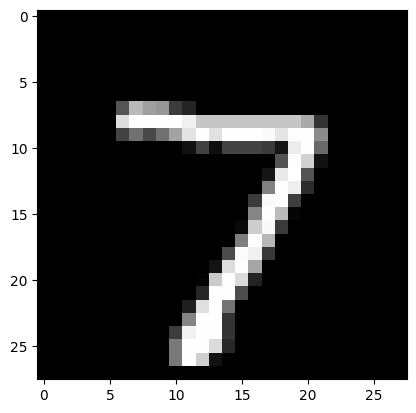

In [ ]:
import matplotlib.pyplot as plt

model.eval()

data,target=test_data[0]

output=model(data)

prediction=output.argmax(dim=1,keepdim=True).item()
print(f'prediction:{prediction}')

image=data.squeeze(0).squeeze(0).cpu().numpy()

plt.imshow(image,cmap='gray')
plt.show()

In [ ]:
# 1. show model parameter checksum (confirms if model has trained weights)
s = 0
for p in model.parameters():
    s += p.detach().abs().sum().item()
print("sum(abs(params)):", s)

# 2. check sample tensor shape & type
print("data.shape:", data.shape)
print("data.min/max:", data.min().item(), data.max().item())
print("model device:", next(model.parameters()).device)


sum(abs(params)): 668.6638917326927
data.shape: torch.Size([1, 28, 28])
data.min/max: 0.0 1.0
model device: cpu


orig data.shape: torch.Size([1, 28, 28]) min/max: 0.0 1.0
model device: cpu
logits: [ 0.0981  0.1383 -0.0038 -0.0328  0.0531  0.0699 -0.0386 -0.1314 -0.0138
  0.104 ]
probs:  [0.1073 0.1117 0.0969 0.0942 0.1026 0.1043 0.0936 0.0853 0.096  0.108 ]
pred:  1  true: 7


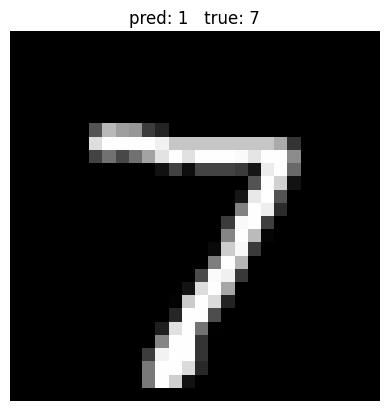

In [ ]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# --- 1) Ensure model in eval mode
model.eval()

# --- 2) Check original sample shapes/values you printed earlier
print("orig data.shape:", data.shape, "min/max:", data.min().item(), data.max().item())
print("model device:", next(model.parameters()).device)

# --- 3) Prepare input: add batch dim + convert float + normalize (MNIST typical)
inp = data.unsqueeze(0).to(torch.float32)   # (1,1,28,28)
# If you used a different mean/std in training, replace these
mean, std = 0.1307, 0.3081
inp = (inp - mean) / std

# move to model device (you said cpu)
device = next(model.parameters()).device
inp = inp.to(device)

# --- 4) Forward pass & inspect raw logits + probs
with torch.no_grad():
    logits = model(inp)            # shape (1,10) EXPECTED
    probs = F.softmax(logits, dim=1)
    logits_np = logits.cpu().numpy()[0]
    probs_np = probs.cpu().numpy()[0]
    pred = int(probs_np.argmax())

print("logits:", np.round(logits_np, 4))
print("probs: ", np.round(probs_np, 4))
print("pred: ", pred, " true:", int(target))

# --- 5) Visualize
image = data.squeeze().cpu().numpy()
plt.imshow(image, cmap='gray')
plt.title(f"pred: {pred}   true: {int(target)}")
plt.axis('off')
plt.show()


In [ ]:
test_loss, test_acc = test()   # use your test() function from earlier
print("Test accuracy (whole set):", test_acc)


NameError: name 'test' is not defined

In [ ]:
import torch, torch.nn.functional as F, numpy as np, matplotlib.pyplot as plt

def prepare_sample(sample_tensor, mean=0.1307, std=0.3081):
    x = sample_tensor.clone().to(torch.float32)
    # If in [0,1] -> normalize (as typical MNIST training)
    if x.max() <= 1.0 and x.min() >= 0.0:
        x = (x - mean) / std
    return x.unsqueeze(0).to(next(model.parameters()).device)

inp = prepare_sample(data)    # data is your test_data[0][0]
with torch.no_grad():
    logits = model(inp)
    probs  = F.softmax(logits, dim=1).cpu().numpy()[0]

print("logits:", np.round(logits.cpu().numpy()[0],4))
print("probs: ", np.round(probs,4))
print("pred: ", probs.argmax(), " true:", int(target))

plt.imshow(data.squeeze().cpu().numpy(), cmap='gray')
plt.title(f"pred: {probs.argmax()} true: {int(target)}")
plt.axis('off')
plt.show()


In [ ]:
batch = next(iter(loaders['test']))
imgs, truths = batch[0], batch[1]
# prepare batch (normalize once if needed)
mean, std = 0.1307, 0.3081
inp = imgs.clone().to(torch.float32)
inp = (inp - mean) / std   # comment this out if your loader already normalized
with torch.no_grad():
    logits = model(inp.to(next(model.parameters()).device))
    preds = logits.argmax(dim=1).cpu().numpy()
print("Batch accuracy (first batch):", (preds == truths.numpy()).mean())
print("Preds sample:", preds[:20])
print("Trues sample:", truths.numpy()[:20])
